# Analyze spin-up NPZ — PRODUCTION

Compare **production** ground-truth outputs (`TEST_MODE = False`). Paths from `scripts/project_paths.py` (`PRODUCTION_CASES`).

| Case | NPZ path (under project root) |
|------|------------------------------|
| more sliding | `outputs/spinup/production/more_sliding/SteadyState_more_sliding_10500yr_ramp4000_1refine_grid.npz` |
| no sliding | `outputs/spinup/production/no_sliding/SteadyState_no_sliding_10500yr_ramp4000_1refine_grid.npz` |

Plots: `outputs/figures/production/{more_sliding,no_sliding}/`

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "scripts" / "project_paths.py").exists()
)
sys.path.insert(0, str(ROOT / "scripts"))
from project_paths import PRODUCTION_CASES

CASES = PRODUCTION_CASES

for label, spec in CASES.items():
    npz_path = spec["grid_npz"]
    h5_path = spec["checkpoint"]
    if not npz_path.is_file():
        raise FileNotFoundError(f"Missing {npz_path}")
    if not h5_path.is_file():
        raise FileNotFoundError(f"Missing {h5_path}")
    print(f"{label}: {npz_path.relative_to(ROOT)} ✓")
print()


def load_case(path):
    """Load one gridded steady-state snapshot written by spinupNewFull."""
    data = np.load(path)

    cfg = json.loads(str(data["cfg_json"]))
    if cfg.get("test_mode") and "production" == "production":
        print(f"Warning: {path.name} was written in test mode.")

    return {
        "label": path.stem.replace("_grid", ""),
        "cfg": cfg,
        "X": data["X"],
        "Y": data["Y"],
        "h": data["thickness"],
        "speed": data["speed"],
        "visc": data["viscosity"],
        "haf": data["height_above_flotation"],
    }


more = load_case(CASES["more_sliding"]["grid_npz"])
less = load_case(CASES["no_sliding"]["grid_npz"])
print("=== PRODUCTION comparison ===\n")
for case in (more, less):
    cfg = case["cfg"]
    print(case["label"])
    print(f"  test_mode = {cfg.get('test_mode', False)}")
    # C = Weertman sliding coefficient: smaller C → more sliding.
    print(f"  C = {cfg['C']} (start {cfg.get('C_start')}, ramp {cfg.get('C_ramp_time')} yr)")
    print(f"  stage time = {cfg.get('coarse_total_time')} yr | dt = {cfg.get('coarse_dt')} yr")
    print(f"  mean h = {case['h'].mean():.2f} m | max speed = {case['speed'].max():.2f} m/yr")
    print(f"  mean visc = {case['visc'].mean():.4g} | grounded = {(case['haf'] > 0).mean():.1%}")
    print(f"  NaNs = {np.isnan(case['h']).sum()}")
    print()

# Scalar summary of how far apart the two basal-sliding cases are.
dh = more["h"] - less["h"]
dspeed = more["speed"] - less["speed"]
dvisc = more["visc"] - less["visc"]
print("more_sliding − no_sliding")
print(f"  Δthickness: mean={dh.mean():+.3f} m, RMS={np.sqrt((dh**2).mean()):.3f} m")
print(f"  Δspeed:     mean={dspeed.mean():+.3f} m/yr, max abs={np.abs(dspeed).max():.3f}")
print(f"  Δviscosity: mean={dvisc.mean():+.4g}, RMS={np.sqrt((dvisc**2).mean()):.4g}")


more_sliding: outputs/spinup/production/more_sliding/SteadyState_more_sliding_10500yr_ramp4000_1refine_grid.npz ✓
no_sliding: outputs/spinup/production/no_sliding/SteadyState_no_sliding_10500yr_ramp4000_1refine_grid.npz ✓

=== PRODUCTION comparison ===

SteadyState_more_sliding_10500yr_ramp4000_1refine
  test_mode = False
  C = 0.001 (start 0.01, ramp 4000.0 yr)
  stage time = 10500.0 yr | dt = 0.25 yr
  mean h = 448.28 m | max speed = 999.32 m/yr
  mean visc = 14.9 | grounded = 87.1%
  NaNs = 0

SteadyState_no_sliding_10500yr_ramp4000_1refine
  test_mode = False
  C = 100.0 (start 0.01, ramp 4000.0 yr)
  stage time = 10500.0 yr | dt = 0.25 yr
  mean h = 1046.58 m | max speed = 1011.55 m/yr
  mean visc = 25.9 | grounded = 88.9%
  NaNs = 0

more_sliding − no_sliding
  Δthickness: mean=-598.297 m, RMS=736.038 m
  Δspeed:     mean=+44.386 m/yr, max abs=617.296
  Δviscosity: mean=-11, RMS=16.95


## Steady-state check (spin-up log)

Domain-mean **thickness** and **speed** sampled during the spin-up (from `outputs/logs/spinup/.../run.log`).
The final `fine_high` stage is shown: if curves flatten after the C-ramp window, the run is approaching steady state.

Older logs without `avg speed=` use **|dh/dt|** as a fallback proxy.


More sliding: outputs/logs/spinup/spinupNewFull-moreSlide_20260627_225451/run.log


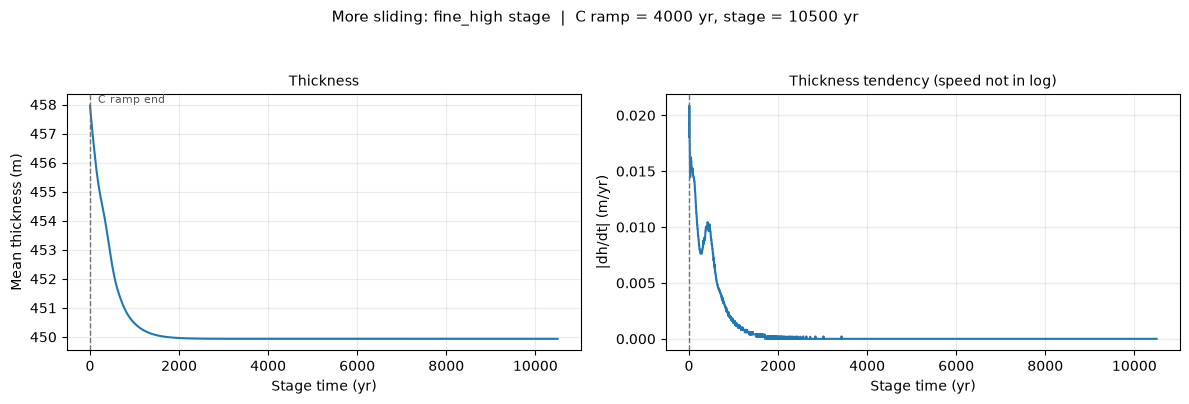

No sliding: outputs/logs/spinup/spinupNewFull-lessSlide_20260628_100917/run.log


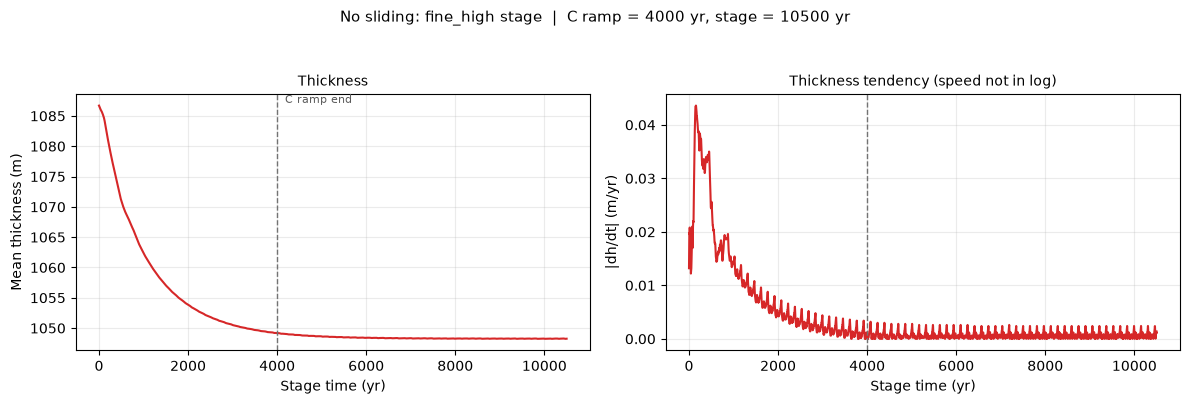

In [2]:
from parse_spinup_log import (
    find_latest_run_log,
    parse_spinup_log,
    stage_local_years,
    stage_points,
    series_or_none,
)


def _stage_ramp_end_yr(stage_pts, cfg):
    """Stage-local time when C reaches target, if that happens within this stage."""
    if not stage_pts:
        return None
    c_target = float(cfg["C"])
    t0 = stage_pts[0].t_yr
    t_end = stage_pts[-1].t_yr - t0
    for point in stage_pts:
        if point.C >= 0.99 * c_target:
            local = point.t_yr - t0
            if local < 0.99 * t_end:
                return local
            return None
    return None


def plot_spinup_steady_state(case_label, case, log_points, *, color):
    stage = "fine_high"
    stage_pts = stage_points(log_points, stage)
    if len(stage_pts) < 3:
        print(f"{case_label}: not enough {stage} diagnostics in log")
        return None

    t_local, h_vals = stage_local_years(stage_pts)
    speeds = series_or_none(stage_pts, "avg_speed")
    ramp_end = _stage_ramp_end_yr(stage_pts, case["cfg"])

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharex=True)
    axes[0].plot(t_local, h_vals, color=color, lw=1.5)
    axes[0].set_ylabel("Mean thickness (m)")
    axes[0].set_title("Thickness", fontsize=10)

    if speeds is not None:
        axes[1].plot(t_local, speeds, color=color, lw=1.5)
        axes[1].set_ylabel("Mean speed (m/yr)")
        axes[1].set_title("Speed", fontsize=10)
    else:
        dh_dt = np.gradient(h_vals, t_local)
        axes[1].plot(t_local, np.abs(dh_dt), color=color, lw=1.5)
        axes[1].set_ylabel("|dh/dt| (m/yr)")
        axes[1].set_title("Thickness tendency (speed not in log)", fontsize=10)

    if ramp_end is not None:
        for ax in axes:
            ax.axvline(ramp_end, color="0.45", ls="--", lw=1.0)
        axes[0].text(
            ramp_end,
            axes[0].get_ylim()[1],
            "  C ramp end",
            va="top",
            ha="left",
            fontsize=8,
            color="0.35",
        )

    for ax in axes:
        ax.set_xlabel("Stage time (yr)")
        ax.grid(True, alpha=0.25)

    ramp_yr = case["cfg"].get("C_ramp_time")
    stage_yr = case["cfg"].get("coarse_total_time")
    fig.suptitle(
        f"{case_label}: {stage} stage  |  C ramp = {ramp_yr:g} yr, stage = {stage_yr:g} yr",
        fontsize=11,
        y=1.05,
    )
    plt.tight_layout()
    return fig


for case_label, case, color in (
    ("More sliding", more, "tab:blue"),
    ("No sliding", less, "tab:red"),
):
    log_path = find_latest_run_log(ROOT, case["cfg"]["case_id"])
    if log_path is None:
        print(f"{case_label}: no run.log found in outputs/logs/spinup/")
        continue
    print(f"{case_label}: {log_path.relative_to(ROOT)}")
    log_points = parse_spinup_log(log_path)
    fig = plot_spinup_steady_state(case_label, case, log_points, color=color)
    if fig is not None:
        plt.show()


## Domain-mean velocity vs time

Mean ice speed during the final `fine_high` stage. Uses `<stem>_history.json` when available,
otherwise the newest `outputs/logs/spinup/.../run.log` (must include `avg speed=`).


More sliding: outputs/logs/spinup/spinupNewFull-moreSlide_20260627_225451/run.log
No sliding: outputs/logs/spinup/spinupNewFull-lessSlide_20260628_100917/run.log


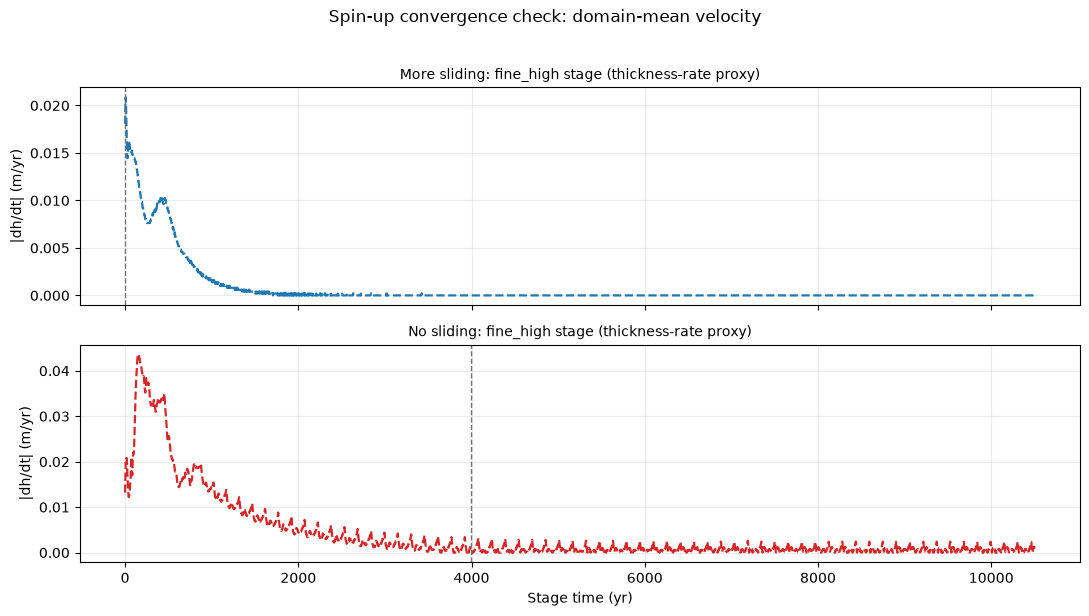

In [3]:
from parse_spinup_log import (
    resolve_spinup_diagnostics,
    stage_local_years,
    stage_points,
    series_or_none,
)


def _stage_ramp_end_yr(stage_pts, cfg):
    if not stage_pts:
        return None
    c_target = float(cfg["C"])
    t0 = stage_pts[0].t_yr
    t_end = stage_pts[-1].t_yr - t0
    for point in stage_pts:
        if point.C >= 0.99 * c_target:
            local = point.t_yr - t0
            if local < 0.99 * t_end:
                return local
            return None
    return None


fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
plotted = False

for ax, (case_label, case, color, case_key) in zip(
    axes,
    (
        ("More sliding", more, "tab:blue", "more_sliding"),
        ("No sliding", less, "tab:red", "no_sliding"),
    ),
):
    points, source = resolve_spinup_diagnostics(ROOT, CASES[case_key])
    if source is None:
        ax.set_title(f"{case_label}: no diagnostics found")
        continue

    print(f"{case_label}: {source.relative_to(ROOT)}")
    stage_pts = stage_points(points, "fine_high")
    speeds = series_or_none(stage_pts, "avg_speed")
    if len(stage_pts) < 3:
        ax.set_title(f"{case_label}: not enough fine_high diagnostics")
        continue

    t_local, h_vals = stage_local_years(stage_pts)
    if speeds is not None:
        ax.plot(t_local, speeds, color=color, lw=1.6)
        ax.set_ylabel("Mean speed (m/yr)")
        speed_note = ""
    else:
        dh_dt = np.abs(np.gradient(h_vals, t_local))
        ax.plot(t_local, dh_dt, color=color, lw=1.6, ls="--")
        ax.set_ylabel("|dh/dt| (m/yr)")
        speed_note = " (thickness-rate proxy)"
    ramp_end = _stage_ramp_end_yr(stage_pts, case["cfg"])
    if ramp_end is not None:
        ax.axvline(ramp_end, color="0.45", ls="--", lw=1.0)
    ax.set_title(f"{case_label}: fine_high stage{speed_note}", fontsize=10)
    ax.grid(True, alpha=0.25)
    plotted = True

axes[-1].set_xlabel("Stage time (yr)")
fig.suptitle("Spin-up convergence check: domain-mean velocity", fontsize=12, y=1.02)
plt.tight_layout()
if plotted:
    plt.show()


## Field comparison plots

Each row has three panels:
1. **More sliding** (`C = 1e-4`) — weak basal friction, ice flows more easily at the bed.
2. **No sliding** (`C = 1e2`) — strong basal friction, ice is more frozen to the bed.
3. **Difference (more − no)** — where the two cases diverge. Red = more sliding higher; blue = no sliding higher.

**What to look for**
- **Thickness:** changes near the grounding line and along the main stream.
- **Speed:** more sliding should show faster flow, especially downstream.
- **Viscosity:** the primary field for variational-inference ground truth; side panels use a **log color scale**, and the difference panel shows **log10(more) − log10(no sliding)**.

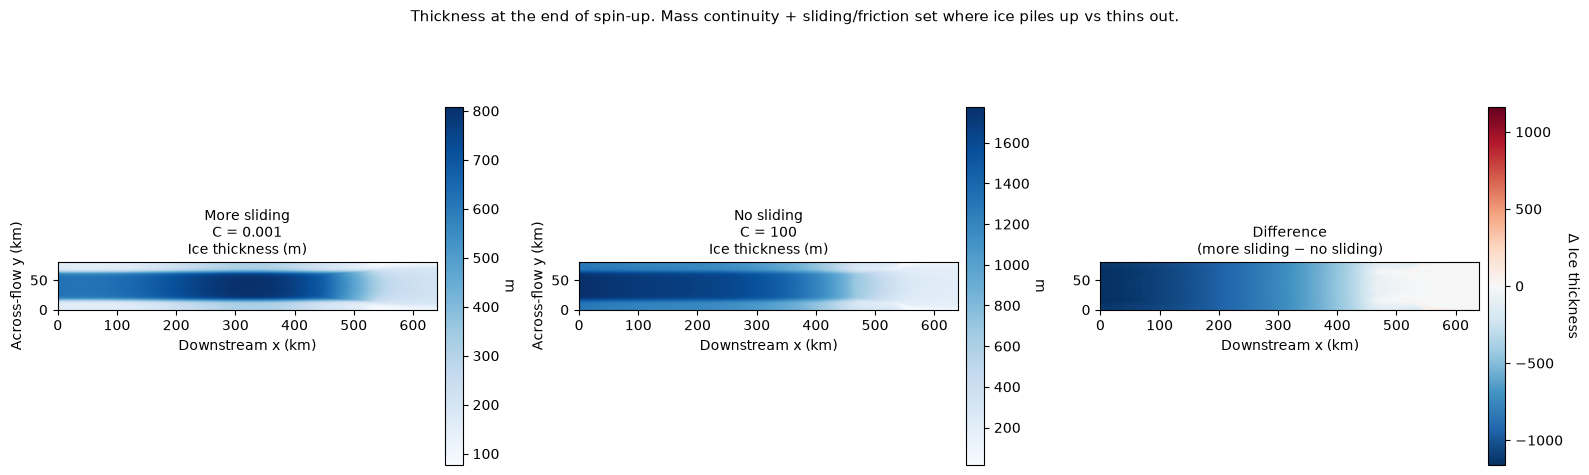

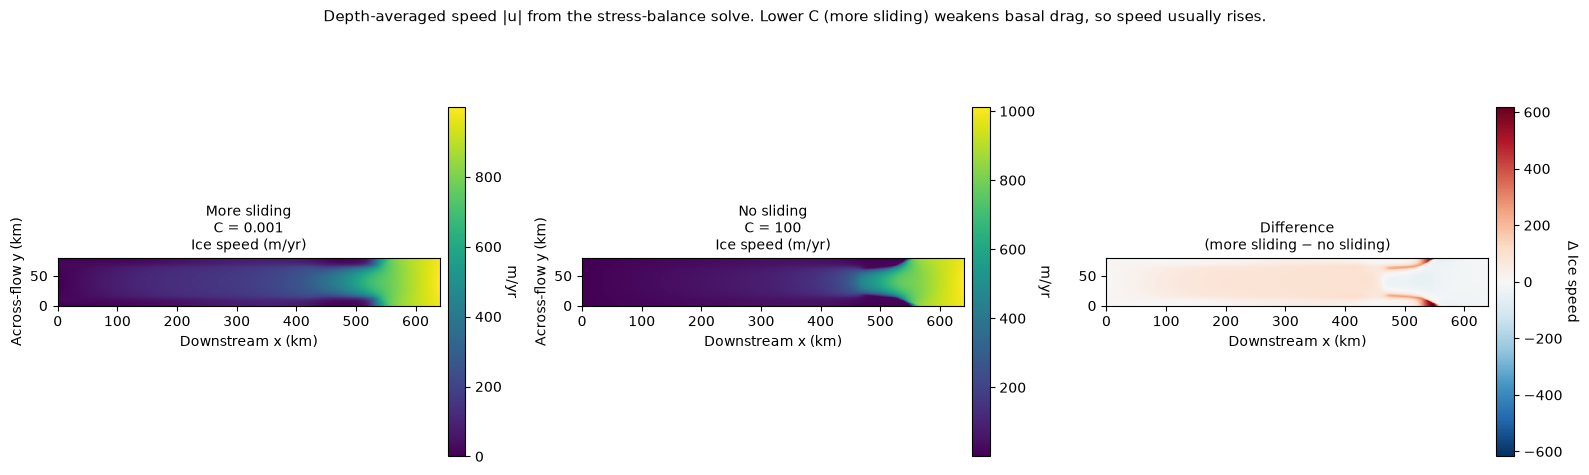

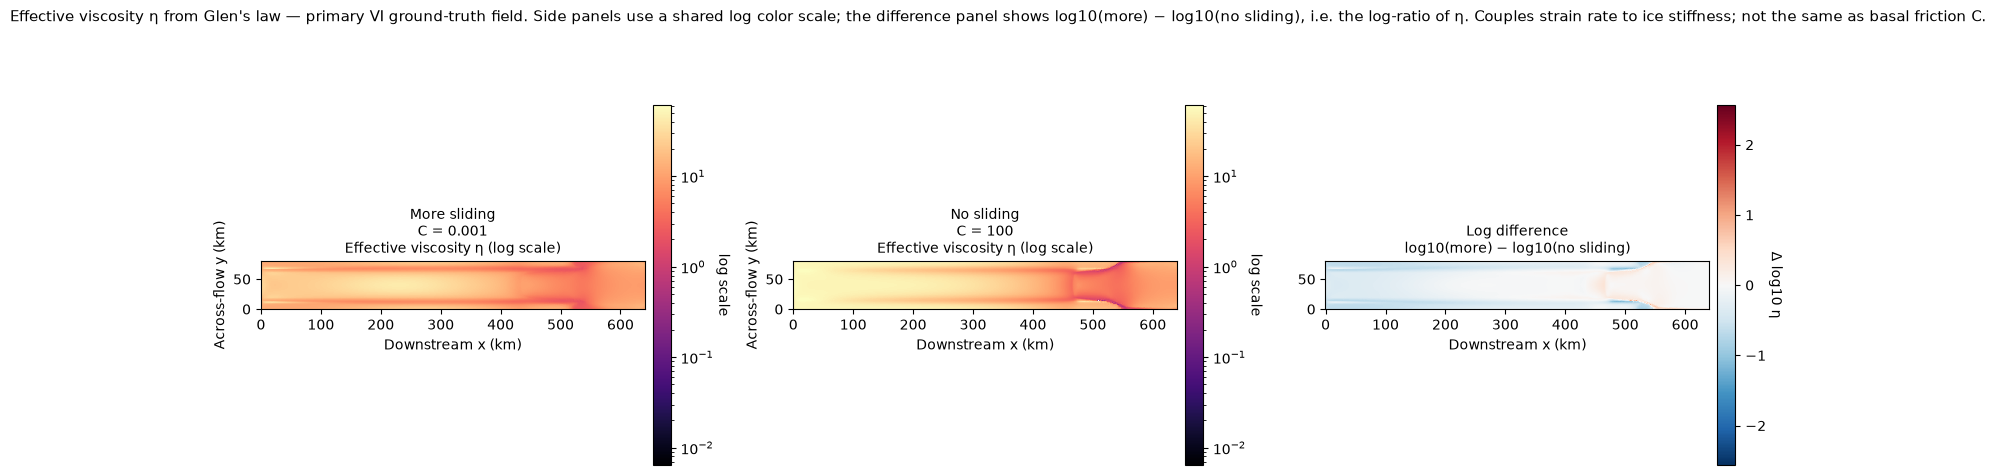

In [4]:
def _log_norm(field_a, field_b):
    """Shared LogNorm for two positive fields (e.g. viscosity)."""
    from matplotlib.colors import LogNorm

    positive = np.concatenate(
        [
            field_a[np.isfinite(field_a) & (field_a > 0)],
            field_b[np.isfinite(field_b) & (field_b > 0)],
        ]
    )
    if positive.size == 0:
        return LogNorm(vmin=1e-6, vmax=1.0)
    vmin = max(float(np.min(positive)), 1e-6)
    vmax = float(np.max(positive))
    if vmax <= vmin:
        vmax = vmin * 10.0
    return LogNorm(vmin=vmin, vmax=vmax)


def _log10_diff(field_a, field_b):
    """log10(a) - log10(b); NaN where either value is non-positive."""
    with np.errstate(divide="ignore", invalid="ignore"):
        log_diff = np.log10(field_a) - np.log10(field_b)
    valid = np.isfinite(field_a) & np.isfinite(field_b) & (field_a > 0) & (field_b > 0)
    return np.where(valid, log_diff, np.nan)


def plot_pair(
    field_key,
    title,
    explanation,
    cmap="viridis",
    diff_cmap="RdBu_r",
    *,
    logscale=False,
):
    """Plot the same physical field for both sliding cases and their difference."""
    a = more[field_key]  # more sliding field
    b = less[field_key]  # less sliding field
    X, Y = more["X"], more["Y"]

    more_c = more["cfg"]["C"]
    less_c = less["cfg"]["C"]

    if logscale:
        diff = _log10_diff(a, b)  # positive → more sliding η is larger (in log space)
    else:
        diff = a - b  # positive → more sliding case is larger there

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
    fig.suptitle(explanation, fontsize=11, y=1.12)

    side_panels = [
        (a, f"More sliding\nC = {more_c:g}\n{title}"),
        (b, f"No sliding\nC = {less_c:g}\n{title}"),
    ]

    field_norm = _log_norm(a, b) if logscale else None

    # Left two panels: absolute fields on the MISMIP+ 640 km × 80 km domain.
    for ax, (field, subtitle) in zip(axes[:2], side_panels):
        im = ax.pcolormesh(
            X / 1e3,
            Y / 1e3,
            field,
            shading="auto",
            cmap=cmap,
            norm=field_norm,
        )
        ax.set_title(subtitle, fontsize=10)
        ax.set_xlabel("Downstream x (km)")  # x = 0 at inflow, x = 640 km at terminus
        ax.set_ylabel("Across-flow y (km)")
        ax.set_aspect("equal")
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
        cbar_label = title.split("(")[-1].rstrip(")") if "(" in title else title
        cbar.ax.set_ylabel(cbar_label, rotation=270, labelpad=12)

    # Right panel: case separation map used to judge ground-truth distinguishability.
    vmax = np.nanmax(np.abs(diff))
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1.0
    im = axes[2].pcolormesh(
        X / 1e3,
        Y / 1e3,
        diff,
        shading="auto",
        cmap=diff_cmap,  # red = more sliding larger, blue = no sliding larger
        vmin=-vmax,
        vmax=vmax,
    )
    if logscale:
        axes[2].set_title(
            "Log difference\nlog10(more) − log10(no sliding)",
            fontsize=10,
        )
    else:
        axes[2].set_title("Difference\n(more sliding − no sliding)", fontsize=10)
    axes[2].set_xlabel("Downstream x (km)")
    axes[2].set_aspect("equal")
    cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.02)
    if logscale:
        cbar.ax.set_ylabel("Δ log10 η", rotation=270, labelpad=12)
    else:
        cbar.ax.set_ylabel(
            "Δ " + title.split("(")[0].strip(),
            rotation=270,
            labelpad=12,
        )

    plt.tight_layout()
    plt.show()


# Three key fields: geometry (h), kinematics (speed), and rheology (viscosity).
PLOT_SPECS = [
    (
        "h",
        "Ice thickness (m)",
        "Thickness at the end of spin-up. "
        "Mass continuity + sliding/friction set where ice piles up vs thins out.",
        "Blues",
        False,
    ),
    (
        "speed",
        "Ice speed (m/yr)",
        "Depth-averaged speed |u| from the stress-balance solve. "
        "Lower C (more sliding) weakens basal drag, so speed usually rises.",
        "viridis",
        False,
    ),
    (
        "visc",
        "Effective viscosity η (log scale)",
        "Effective viscosity η from Glen's law — primary VI ground-truth field. "
        "Side panels use a shared log color scale; the difference panel shows "
        "log10(more) − log10(no sliding), i.e. the log-ratio of η. "
        "Couples strain rate to ice stiffness; not the same as basal friction C.",
        "magma",
        True,
    ),
]

for field_key, title, explanation, cmap, logscale in PLOT_SPECS:
    plot_pair(field_key, title, explanation, cmap=cmap, logscale=logscale)


## Grounding line

- **Background:** ice thickness (m).
- **Contour (GL):** `height_above_flotation = 0` — the approximate grounding line.
  - **HAF > 0** → grounded ice
  - **HAF ≤ 0** → floating ice shelf

Compare how basal sliding shifts the grounding-line position between cases.

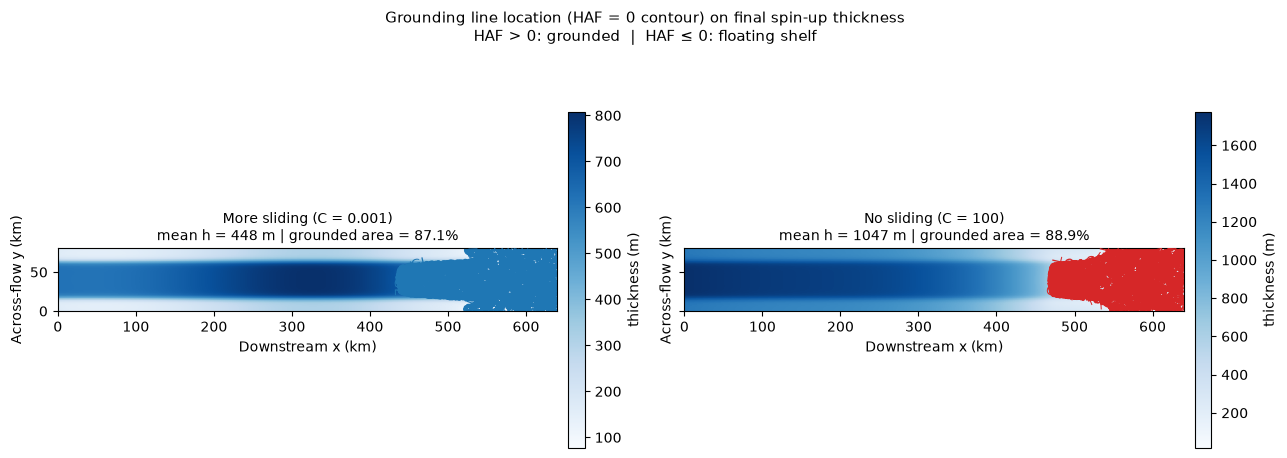

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)

for ax, case, color, case_label in zip(
    axes,
    (more, less),
    ("tab:blue", "tab:red"),
    (f"More sliding (C = {more['cfg']['C']:g})", f"No sliding (C = {less['cfg']['C']:g})"),
):
    X, Y, haf = case["X"], case["Y"], case["haf"]
    h = case["h"]

    # Thickness shows ice geometry; HAF contour marks where ice lifts off the bed.
    im = ax.pcolormesh(X / 1e3, Y / 1e3, h, shading="auto", cmap="Blues")
    cs = ax.contour(
        X / 1e3,
        Y / 1e3,
        haf,
        levels=[0],  # HAF = 0 is the flotation / grounding-line criterion
        colors=[color],
        linewidths=2.5,
    )
    ax.clabel(cs, fmt="GL", fontsize=9)

    # Fraction of domain that is still grounded (HAF > 0).
    grounded_frac = 100.0 * float((haf > 0).mean())
    ax.set_title(
        f"{case_label}\n"
        f"mean h = {h.mean():.0f} m | grounded area = {grounded_frac:.1f}%",
        fontsize=10,
    )
    ax.set_xlabel("Downstream x (km)")
    ax.set_ylabel("Across-flow y (km)")
    ax.set_aspect("equal")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label="thickness (m)")

fig.suptitle(
    "Grounding line location (HAF = 0 contour) on final spin-up thickness\n"
    "HAF > 0: grounded  |  HAF ≤ 0: floating shelf",
    fontsize=11,
    y=1.08,
)
plt.tight_layout()
plt.show()